# AR Baseline Models — Growth (ISM) & Inflation (CPI)

Baseline univariate AR models for 6-9 month-ahead forecasts of:
- **Growth**: ISM New Orders index, lagged on itself  **AR(1)**
- **Inflation**: CPI, lagged on itself  **AR(2)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Load data

In [2]:
xl = pd.ExcelFile("AR_Model_Data.xlsx")
growth = xl.parse("Growth"); growth.columns = ["date", "ism"]
infl = xl.parse("Inflation"); infl.columns = ["date", "cpi"]

growth["date"] = pd.to_datetime(growth["date"])
infl["date"] = pd.to_datetime(infl["date"])
growth = growth.set_index("date").sort_index()
infl = infl.set_index("date").sort_index()

ism = growth["ism"].dropna(); ism.index.freq = "ME"
cpi = infl["cpi"].dropna(); cpi.index.freq = "ME"

print(f"ISM: {ism.index[0].date()} to {ism.index[-1].date()}  ({len(ism)} obs)")
print(f"CPI: {cpi.index[0].date()} to {cpi.index[-1].date()}  ({len(cpi)} obs)")
ism.tail()


ISM: 1996-09-30 to 2026-08-31  (360 obs)
CPI: 1947-01-31 to 2026-08-31  (956 obs)


date
2026-04-30    54.1
2026-05-31    56.8
2026-06-30    56.0
2026-07-31    56.7
2026-08-31    53.7
Freq: ME, Name: ism, dtype: float64

## 2. Stationarity check

An AR model assumes the series is (roughly) stationary: mean-reverting,
not trending forever. ISM New Orders oscillates around 50, so the level
itself should be fine. CPI is a price *index* that trends upward, so the
level is almost certainly non-stationary; we test the level, the month-over-month
% change, and the year-over-year % change and use whichever is stationary.

Augmented Dickey-Fuller test: null hypothesis = non-stationary (unit root).
A small p-value (< 0.05) rejects that, i.e. the series is stationary.


In [3]:
def adf_report(series, name):
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    stat, pval = result[0], result[1]
    verdict = "stationary" if pval < 0.05 else "NOT stationary"
    print(f"{name:14s}  ADF stat={stat:7.3f}   p-value={pval:.4f}   -> {verdict}")

cpi_mom = cpi.pct_change().dropna() * 100
cpi_yoy = cpi.pct_change(12).dropna() * 100
cpi_yoy.index.freq = "ME"

adf_report(ism, "ISM level")
adf_report(cpi, "CPI level")
adf_report(cpi_mom, "CPI MoM %")
adf_report(cpi_yoy, "CPI YoY %")


ISM level       ADF stat= -5.157   p-value=0.0000   -> stationary
CPI level       ADF stat=  2.972   p-value=1.0000   -> NOT stationary
CPI MoM %       ADF stat= -4.649   p-value=0.0001   -> stationary
CPI YoY %       ADF stat= -3.802   p-value=0.0029   -> stationary


**Conclusion:** ISM level is stationary so we acan model it directly. CPI level is not
(p ≈ 1.0) — modeling it directly would just extrapolate the upward trend, not
actually capture inflation dynamics. CPI YoY % change is stationary and is
also literally "the inflation rate," so that's what we model. We'll translate
the YoY forecast back into an implied CPI level at the end for reference.


## 3. Lag order selection


### 3a. AIC search (in-sample)


In [4]:
MAX_LAG = 12

def select_order(series, max_lag=MAX_LAG):
    rows = []
    for p in range(1, max_lag + 1):
        m = AutoReg(series, lags=p).fit()
        rows.append({"p": p, "aic": m.aic, "bic": m.bic})
    table = pd.DataFrame(rows)
    best_p = int(table.loc[table["aic"].idxmin(), "p"])
    return best_p, table

ism_aic_p, ism_order_table = select_order(ism)
yoy_aic_p, yoy_order_table = select_order(cpi_yoy)

print(f"ISM New Orders: AIC-selected p = {ism_aic_p}  (searched 1-{MAX_LAG})")
print(f"CPI YoY %:      AIC-selected p = {yoy_aic_p}  (searched 1-{MAX_LAG})")


ISM New Orders: AIC-selected p = 12  (searched 1-12)
CPI YoY %:      AIC-selected p = 12  (searched 1-12)


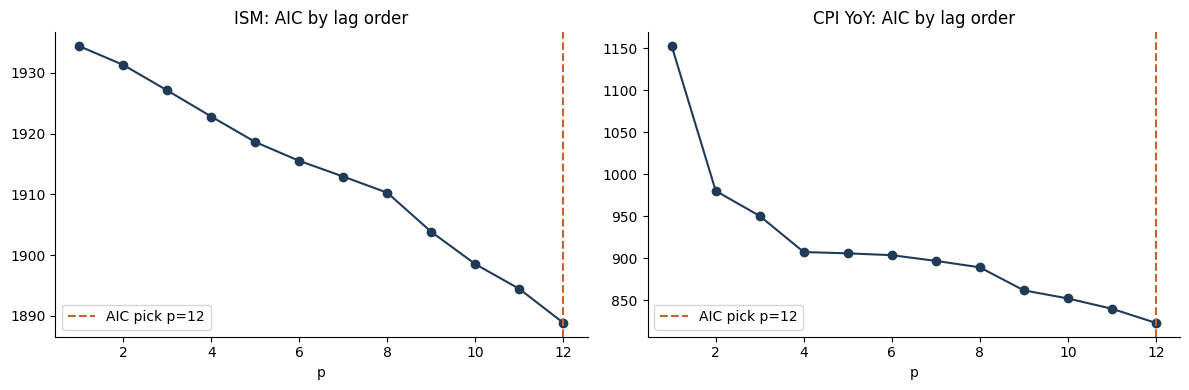

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ism_order_table["p"], ism_order_table["aic"], marker="o", color="#1f3b57")
axes[0].axvline(ism_aic_p, color="#c9622a", ls="--", label=f"AIC pick p={ism_aic_p}")
axes[0].set_title("ISM: AIC by lag order"); axes[0].set_xlabel("p"); axes[0].legend()

axes[1].plot(yoy_order_table["p"], yoy_order_table["aic"], marker="o", color="#1f3b57")
axes[1].axvline(yoy_aic_p, color="#c9622a", ls="--", label=f"AIC pick p={yoy_aic_p}")
axes[1].set_title("CPI YoY: AIC by lag order"); axes[1].set_xlabel("p"); axes[1].legend()
plt.tight_layout(); plt.show()


AIC keeps decreasing all the way to the p=12 boundary for both series (and
if you let the search run past 12, it keeps climbing higher still, with no
interior minimum). On ~30 years of monthly ISM data and a CPI YoY series
whose calculation already bakes in strong 12-month overlap, that's a sign
AIC is chasing noise, not a real signal. Worth checking which individual
lags are actually statistically significant:


In [6]:
def significant_lags(series, p):
    m = AutoReg(series, lags=p).fit()
    sig = m.pvalues[m.pvalues < 0.05]
    return sig

print("ISM AR(12): significant coefficients (p<0.05)")
print(significant_lags(ism, ism_aic_p))
print()
print("CPI YoY AR(12): significant coefficients (p<0.05)")
print(significant_lags(cpi_yoy, yoy_aic_p))


ISM AR(12): significant coefficients (p<0.05)
const     1.773e-07
ism.L1    6.577e-62
dtype: float64

CPI YoY AR(12): significant coefficients (p<0.05)
const      2.278e-05
cpi.L1     0.000e+00
cpi.L2     9.363e-12
cpi.L11    1.565e-03
dtype: float64


For ISM, only the constant and lag-1 are significant — the other 11 lags
are noise. For CPI YoY, lag-1 and lag-2 (plus one distant, likely spurious,
lag) are significant. That already points toward much smaller models than
AIC's pick.

### 3b. The real test: out-of-sample RMSE at the 6-9 month horizon

AIC is in-sample. What actually matters is: if you'd used this model to
forecast 6-9 months ahead in the past, how far off would it have been?
We answer that directly with a rolling-origin backtest — same holdout
methodology as Section 5, just run here for a few candidate lag orders
before committing to one.


In [7]:
TEST_FRAC = 0.20
HORIZON = 12

def train_test_split(series, test_frac=TEST_FRAC):
    n_test = int(round(len(series) * test_frac))
    return series.iloc[:-n_test], series.iloc[-n_test:]

def horizon_rmse_for_p(series, p, test_frac=TEST_FRAC, max_horizon=HORIZON):
    """Rolling-origin out-of-sample RMSE by forecast horizon, for a FIXED lag order p."""
    train, test = train_test_split(series, test_frac)
    horizon_errors = {h: [] for h in range(1, max_horizon + 1)}
    full_index = series.index
    test_start_pos = len(train)
    for origin_pos in range(test_start_pos, len(full_index)):
        origin_date = full_index[origin_pos]
        hist = series.loc[:origin_date].iloc[:-1]
        if len(hist) < p + 1:
            continue
        m = AutoReg(hist, lags=p).fit()
        max_h = min(max_horizon, len(full_index) - origin_pos)
        if max_h < 1:
            continue
        fc = m.forecast(steps=max_h)
        for h in range(1, max_h + 1):
            actual = series.iloc[origin_pos + h - 1]
            pred = fc.iloc[h - 1]
            horizon_errors[h].append((actual - pred) ** 2)
    return {h: (float(np.sqrt(np.mean(e))) if e else np.nan) for h, e in horizon_errors.items()}

candidate_ps = [1, 2, 3, 6, 12]
report_horizons = [1, 3, 6, 7, 8, 9, 12]

ism_compare = pd.DataFrame({p: horizon_rmse_for_p(ism, p) for p in candidate_ps}).T
ism_compare.index.name = "p"
ism_compare = ism_compare[report_horizons]
ism_compare.columns = [f"h={h}" for h in report_horizons]

yoy_compare = pd.DataFrame({p: horizon_rmse_for_p(cpi_yoy, p) for p in candidate_ps}).T
yoy_compare.index.name = "p"
yoy_compare = yoy_compare[report_horizons]
yoy_compare.columns = [f"h={h}" for h in report_horizons]

print("ISM: out-of-sample RMSE by candidate lag order")
display(ism_compare.round(2))
print()
print("CPI YoY: out-of-sample RMSE by candidate lag order")
display(yoy_compare.round(3))


ISM: out-of-sample RMSE by candidate lag order


,h=1,h=3,h=6,h=7,h=8,h=9,h=12
p,,,,,,,
1,2.68,3.91,5.31,5.70,5.95,6.17,6.57
2,2.74,4.06,5.51,5.89,6.13,6.33,6.66
3,2.74,3.98,5.37,5.75,5.99,6.20,6.56
6,2.75,3.98,5.59,6.02,6.28,6.49,6.77
12,2.81,4.03,5.43,5.80,6.07,6.40,7.37



CPI YoY: out-of-sample RMSE by candidate lag order


,h=1,h=3,h=6,h=7,h=8,h=9,h=12
p,,,,,,,
1,0.365,0.813,1.242,1.363,1.486,1.608,1.933
2,0.325,0.772,1.174,1.283,1.394,1.509,1.818
3,0.327,0.774,1.176,1.285,1.398,1.515,1.834
6,0.325,0.764,1.139,1.237,1.345,1.461,1.778
12,0.321,0.747,1.142,1.251,1.366,1.490,1.829


In [ ]:
FINAL_ISM_P = 1
FINAL_YOY_P = 2


Final ISM order: AR(1)
Final CPI YoY order: AR(2)


## 4. Fit the final models on the full sample & forecast forward

Fit each AR(p) (using the final orders from Section 3) on the complete
history, then forecast 12 months ahead (recursive, i.e. each forecasted
value feeds the next month's lag) so we can read off the 6-9 month-ahead
window specifically.


In [9]:
def fit_and_forecast(series, p, horizon=HORIZON):
    model = AutoReg(series, lags=p).fit()
    fc = model.forecast(steps=horizon)
    fc.index = pd.date_range(series.index[-1] + pd.offsets.MonthEnd(1), periods=horizon, freq="ME")
    return model, fc

ism_model, ism_fc = fit_and_forecast(ism, FINAL_ISM_P)
yoy_model, yoy_fc = fit_and_forecast(cpi_yoy, FINAL_YOY_P)

print(ism_model.summary())


                            AutoReg Model Results                             
Dep. Variable:                    ism   No. Observations:                  359
Model:                     AutoReg(1)   Log Likelihood                -964.188
Method:               Conditional MLE   S.D. of innovations              3.550
Date:                Mon, 21 Sep 2026   AIC                           1934.376
Time:                        21:55:17   BIC                           1946.026
Sample:                    10-31-1996   HQIC                          1939.009
                         - 08-31-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.5920      1.480      5.128      0.000       4.691      10.494
ism.L1         0.8613      0.027     32.114      0.000       0.809       0.914
                                    Roots           

In [10]:
print(yoy_model.summary())


                            AutoReg Model Results                             
Dep. Variable:                    cpi   No. Observations:                  942
Model:                     AutoReg(2)   Log Likelihood                -486.018
Method:               Conditional MLE   S.D. of innovations              0.405
Date:                Mon, 21 Sep 2026   AIC                            980.035
Time:                        21:55:17   BIC                            999.427
Sample:                    03-31-1948   HQIC                           987.427
                         - 08-31-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0609      0.021      2.903      0.004       0.020       0.102
cpi.L1         1.3885      0.030     46.744      0.000       1.330       1.447
cpi.L2        -0.4069      0.030    -13.738      0.0

In [11]:
# translate the CPI YoY forecast back into an implied CPI level path:
# CPI_t = CPI_(t-12) * (1 + YoY_t / 100)
def cpi_level_from_yoy(cpi_level_hist, yoy_fc):
    combined = cpi_level_hist.copy()
    out = {}
    for date, yoy_val in yoy_fc.items():
        base_date = (date - pd.DateOffset(years=1)) + pd.offsets.MonthEnd(0)
        base_val = combined.get(base_date, combined.iloc[-12])
        level = base_val * (1 + yoy_val / 100)
        combined.loc[date] = level
        out[date] = level
    return pd.Series(out)

cpi_level_fc = cpi_level_from_yoy(cpi, yoy_fc)


### Forecast charts

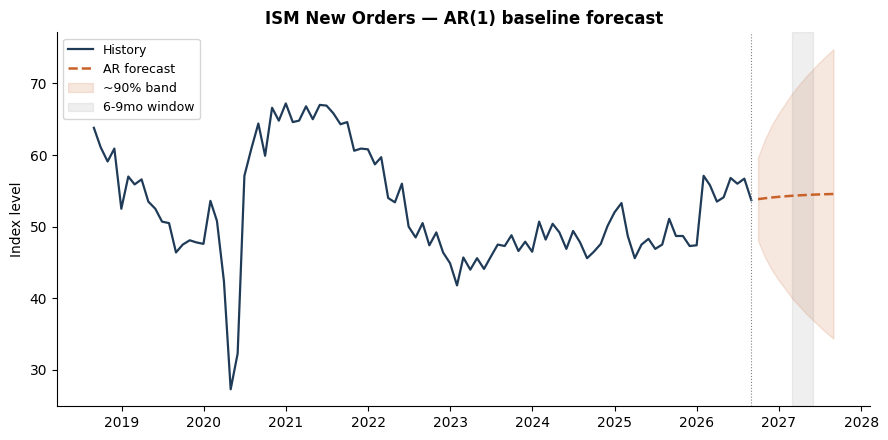

In [12]:
def plot_forecast(hist, fc, resid_std, title, ylabel, hist_years=8):
    fig, ax = plt.subplots()
    h = hist[hist.index >= hist.index[-1] - pd.DateOffset(years=hist_years)]
    ax.plot(h.index, h.values, color="#1f3b57", lw=1.6, label="History")
    ax.plot(fc.index, fc.values, color="#c9622a", lw=1.8, ls="--", label="AR forecast")
    steps = np.arange(1, len(fc) + 1)
    band = resid_std * np.sqrt(steps)
    ax.fill_between(fc.index, fc.values - 1.64*band, fc.values + 1.64*band,
                     color="#c9622a", alpha=0.15, label="~90% band")
    if len(fc) >= 9:
        ax.axvspan(fc.index[5], fc.index[8], color="gray", alpha=0.12, label="6-9mo window")
    ax.axvline(hist.index[-1], color="gray", lw=0.8, ls=":")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_forecast(ism, ism_fc, ism_model.resid.std(),
              f"ISM New Orders — AR({FINAL_ISM_P}) baseline forecast", "Index level")


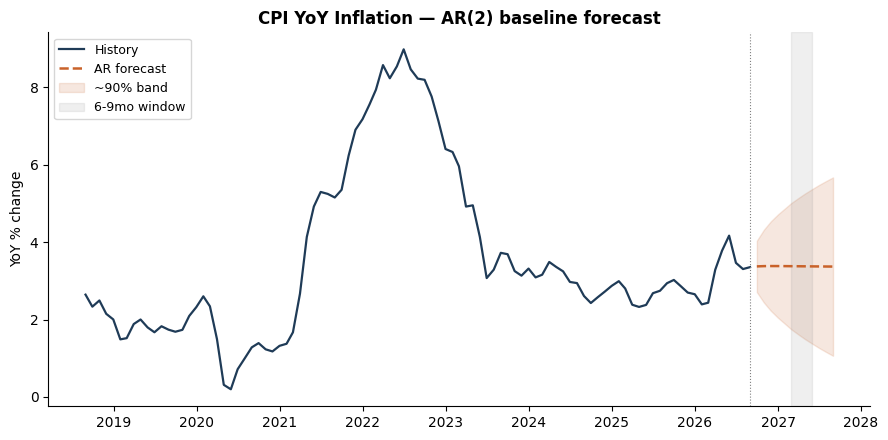

In [13]:
plot_forecast(cpi_yoy, yoy_fc, yoy_model.resid.std(),
              f"CPI YoY Inflation — AR({FINAL_YOY_P}) baseline forecast", "YoY % change")


### 6-9 month-ahead forecast table

In [14]:
window = ism_fc.index[5:9]  # months-ahead 6,7,8,9
summary = pd.DataFrame({
    "months_ahead": range(1, HORIZON + 1),
    "ISM_forecast": ism_fc.values,
    "CPI_YoY_forecast_%": yoy_fc.values,
    "CPI_level_implied": cpi_level_fc.values,
}, index=ism_fc.index.strftime("%Y-%m"))
summary.index.name = "month"

def highlight_window(row):
    return ["background-color: #fde9dc" if row["months_ahead"] in (6,7,8,9) else "" for _ in row]

summary.style.apply(highlight_window, axis=1)


,months_ahead,ISM_forecast,CPI_YoY_forecast_%,CPI_level_implied
month,,,,
2026-09,1,53.843578,3.372414,335.179883
2026-10,2,53.967240,3.379346,335.625181
2026-11,3,54.073750,3.381079,336.053636
2026-12,4,54.165487,3.380664,337.053014
2027-01,5,54.244499,3.379384,337.624663
2027-02,6,54.312552,3.377775,338.520862
2027-03,7,54.371166,3.376062,341.443895
2027-04,8,54.421649,3.374337,343.623533
2027-05,9,54.465131,3.372640,345.242909


## 5. Train/test split & out-of-sample RMSE (final models)


In [15]:
def walk_forward_backtest(series, p, test_frac=TEST_FRAC, max_horizon=HORIZON):
    train, test = train_test_split(series, test_frac)

    # one-step-ahead walk-forward
    history = train.copy()
    actuals, preds = [], []
    for date in test.index:
        m = AutoReg(history, lags=p).fit()
        preds.append(m.forecast(steps=1).iloc[0])
        actuals.append(series.loc[date])
        history = pd.concat([history, series.loc[[date]]])
    actuals = pd.Series(actuals, index=test.index)
    preds = pd.Series(preds, index=test.index)
    rmse_1step = float(np.sqrt(np.mean((actuals - preds) ** 2)))

    horizon_rmse = horizon_rmse_for_p(series, p, test_frac, max_horizon)

    return {"p": p, "train": train, "test": test, "actuals": actuals, "preds": preds,
            "rmse_1step": rmse_1step, "horizon_rmse": horizon_rmse}

ism_bt = walk_forward_backtest(ism, FINAL_ISM_P)
yoy_bt = walk_forward_backtest(cpi_yoy, FINAL_YOY_P)

print(f"ISM      -- train {len(ism_bt['train'])} / test {len(ism_bt['test'])} obs, AR({FINAL_ISM_P})")
print(f"  1-step-ahead test RMSE: {ism_bt['rmse_1step']:.3f}")
print(f"CPI YoY  -- train {len(yoy_bt['train'])} / test {len(yoy_bt['test'])} obs, AR({FINAL_YOY_P})")
print(f"  1-step-ahead test RMSE: {yoy_bt['rmse_1step']:.3f}")


ISM      -- train 288 / test 72 obs, AR(1)
  1-step-ahead test RMSE: 2.677
CPI YoY  -- train 755 / test 189 obs, AR(2)
  1-step-ahead test RMSE: 0.325


### Backtest chart: test-period actuals vs. 1-step-ahead forecasts

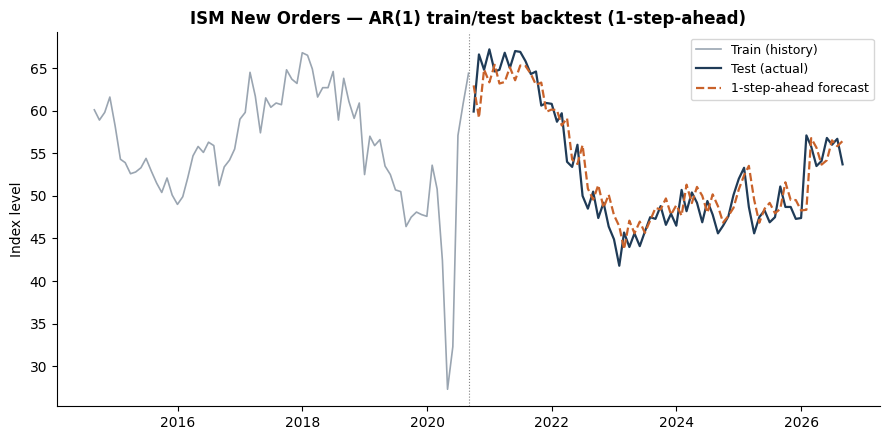

In [16]:
def plot_backtest(train, test, actuals, preds, title, ylabel, hist_years=6):
    fig, ax = plt.subplots()
    h = train[train.index >= train.index[-1] - pd.DateOffset(years=hist_years)]
    ax.plot(h.index, h.values, color="#9aa5b1", lw=1.2, label="Train (history)")
    ax.plot(test.index, test.values, color="#1f3b57", lw=1.6, label="Test (actual)")
    ax.plot(preds.index, preds.values, color="#c9622a", lw=1.6, ls="--", label="1-step-ahead forecast")
    ax.axvline(train.index[-1], color="gray", lw=0.8, ls=":")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()

plot_backtest(ism_bt["train"], ism_bt["test"], ism_bt["actuals"], ism_bt["preds"],
              f"ISM New Orders — AR({FINAL_ISM_P}) train/test backtest (1-step-ahead)", "Index level")


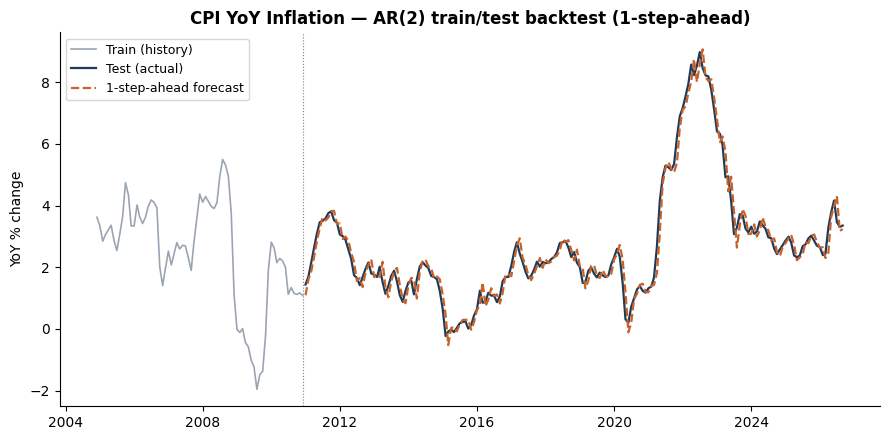

In [17]:
plot_backtest(yoy_bt["train"], yoy_bt["test"], yoy_bt["actuals"], yoy_bt["preds"],
              f"CPI YoY Inflation — AR({FINAL_YOY_P}) train/test backtest (1-step-ahead)", "YoY % change")


### RMSE by forecast horizon (the 6-9 month window is what matters here)

In [18]:
horizon_df = pd.DataFrame({
    "months_ahead": range(1, HORIZON + 1),
    "ISM_RMSE": [ism_bt["horizon_rmse"][h] for h in range(1, HORIZON + 1)],
    "CPI_YoY_RMSE": [yoy_bt["horizon_rmse"][h] for h in range(1, HORIZON + 1)],
}).set_index("months_ahead")

def highlight_window(row):
    return ["background-color: #fde9dc" if row.name in (6,7,8,9) else "" for _ in row]

horizon_df.style.apply(highlight_window, axis=1).format("{:.3f}")


,ISM_RMSE,CPI_YoY_RMSE
months_ahead,,
1,2.677,0.325
2,3.332,0.581
3,3.911,0.772
4,4.447,0.922
5,4.852,1.052
6,5.305,1.174
7,5.699,1.283
8,5.946,1.394
9,6.168,1.509


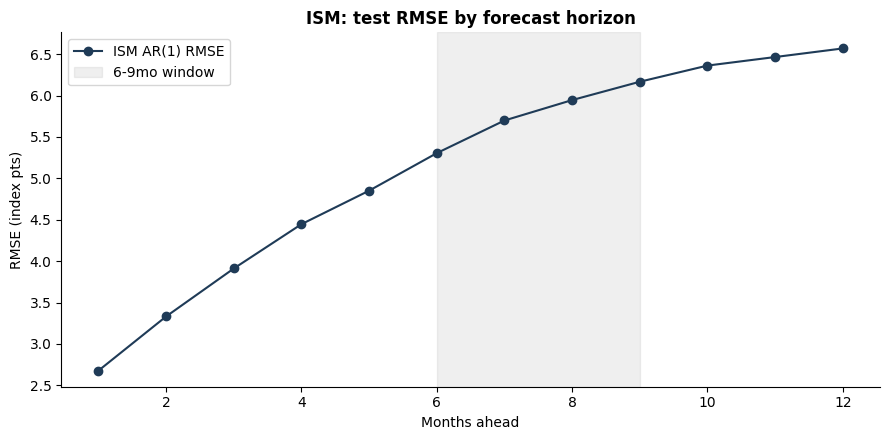

In [19]:
fig, ax = plt.subplots()
ax.plot(horizon_df.index, horizon_df["ISM_RMSE"], marker="o", color="#1f3b57", label=f"ISM AR({FINAL_ISM_P}) RMSE")
ax.axvspan(6, 9, color="gray", alpha=0.12, label="6-9mo window")
ax.set_xlabel("Months ahead"); ax.set_ylabel("RMSE (index pts)")
ax.set_title("ISM: test RMSE by forecast horizon", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()


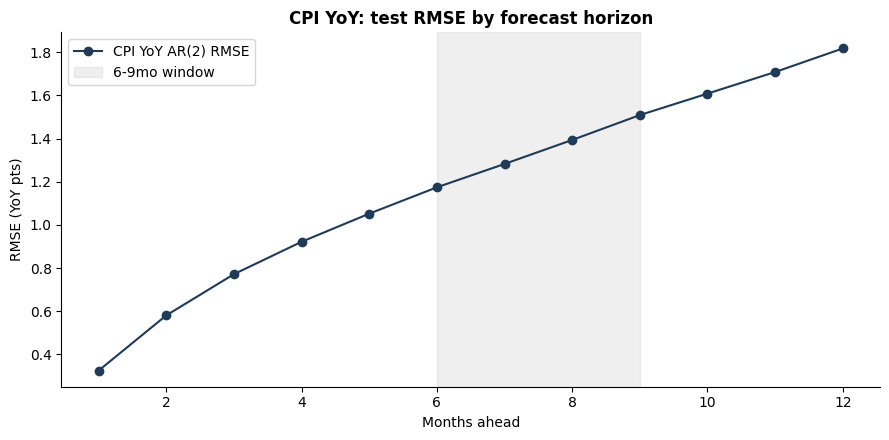

In [20]:
fig, ax = plt.subplots()
ax.plot(horizon_df.index, horizon_df["CPI_YoY_RMSE"], marker="o", color="#1f3b57", label=f"CPI YoY AR({FINAL_YOY_P}) RMSE")
ax.axvspan(6, 9, color="gray", alpha=0.12, label="6-9mo window")
ax.set_xlabel("Months ahead"); ax.set_ylabel("RMSE (YoY pts)")
ax.set_title("CPI YoY: test RMSE by forecast horizon", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()
